In [ ]:
# Import
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
from transformers import BertTokenizer, AutoProcessor, AutoModelForCausalLM, BertModel, AutoProcessor, LlavaForConditionalGeneration,  BitsAndBytesConfig, TrainingArguments, Trainer, AutoModel, AutoTokenizer
import torch
import torch.nn as nn
import torchvision.models as models
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
import torchvision.transforms as T
import torchvision.transforms as transforms
import torch.optim as optim
import time
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import re
import os
import seaborn as sns
import pandas as pd
import numpy as np


In [ ]:
# Load VQA-RAD dataset
ds = load_dataset("flaviagiammarino/vqa-rad")
print(ds)
print("Train Size: ", len(ds["train"]))
print("Test Size: ", len(ds["test"]))
sample_image = ds["train"][0]["image"]
print("Image Size:", sample_image.size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})
Train Size:  1793
Test Size:  451
Image Size: (566, 555)



Data Level Sample 1
Question: are regions of the brain infarcted?
Answer: yes 



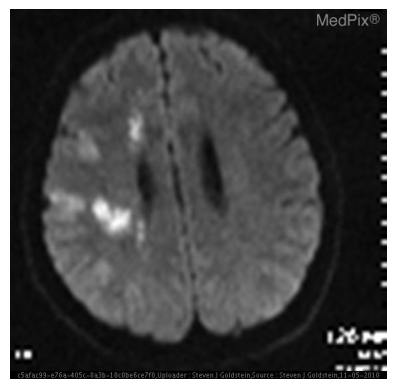


Data Level Sample 2
Question: are the lungs normal appearing?
Answer: no 



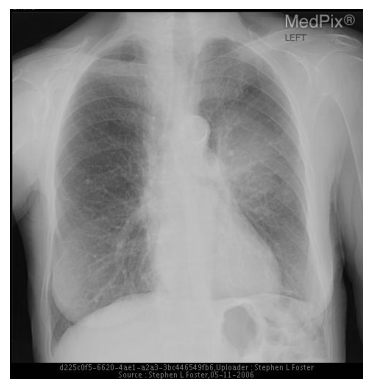


Data Level Sample 3
Question: which organ system is abnormal in this image?
Answer: cardiovascular 



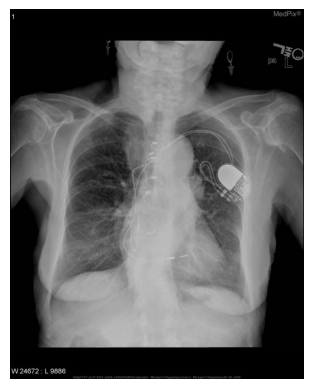

In [ ]:
for i in range(3):
    sample = ds["train"][i]

    print(f"\nData Level Sample {i+1}")
    print("Question:", sample['question'])
    print("Answer:", sample['answer'], "\n")

    plt.imshow(sample['image'])
    plt.axis('off')
    plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**CNN+LSTM (Baseline Model)(No training)**

In [ ]:
# 1. CONFIGURATION (Tuned for BioMedBERT)
class Config:
    hidden_dim = 512
    batch_size = 16      
    lr = 2e-5          
    weight_decay = 1e-4
    epochs = 20
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # bert_model = "dmis-lab/biobert-v1.1"
    bert_model = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

# 2. UTILS
def build_answer_vocab(answers, min_freq=2):
    print("Building Answer Vocabulary...")
    clean_answers = [str(a).lower().strip() for a in answers]
    counter = Counter(clean_answers)
    valid_answers = [ans for ans, count in counter.items() if count >= min_freq]
    ans2idx = {ans: i for i, ans in enumerate(valid_answers)}
    print(f"Found {len(counter)} unique answers. Keeping {len(ans2idx)} frequent answers.")
    return ans2idx

# 3. DATASET (Specific for BERT)
tokenizer = AutoTokenizer.from_pretrained(Config.bert_model)

class VQABertDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, ans2idx, transform=None):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.ans2idx = ans2idx
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]

        # Image
        image = item['image'].convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Question - Tokenize for BERT
        question = item['question']
        encoding = self.tokenizer(
            question,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=32 # Questions are short
        )

        # Answer
        answer_text = str(item['answer']).lower().strip()
        label = self.ans2idx.get(answer_text, -1)

        # .squeeze(0) removes the extra batch dimension added by tokenizer
        return image, encoding['input_ids'].squeeze(0), encoding['attention_mask'].squeeze(0), torch.tensor(label)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# 4. BIOBERT MODEL ARCHITECTURE
class BioBertVQAModel(nn.Module):
    def __init__(self, num_classes, hidden_dim=512):
        super(BioBertVQAModel, self).__init__()

        # --- A. IMAGE ENCODER (ResNet50) ---
        resnet = models.resnet50(pretrained=True)
        modules = list(resnet.children())[:-1] 
        self.resnet = nn.Sequential(*modules)

        # FREEZE ResNet (Prevent Overfitting)
        for param in self.resnet.parameters():
            param.requires_grad = False

        self.img_proj = nn.Linear(2048, hidden_dim)

        # --- B. TEXT ENCODER (BioBERT) ---
        print(f">>> Loading {Config.bert_model}...")
        self.bert = AutoModel.from_pretrained(Config.bert_model)

        # FREEZE First 10 Layers of BERT (Only train last 2)
        layers_to_freeze = 10
        for name, param in self.bert.named_parameters():
            if "encoder.layer" in name:
                layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
                if layer_num < layers_to_freeze:
                    param.requires_grad = False

        # --- C. CLASSIFIER ---
        # BERT output (768) + Image (hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(768 + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, images, input_ids, attention_mask):
        # 1. Image Features
        img_feats = self.resnet(images)         
        img_feats = img_feats.view(img_feats.size(0), -1)
        img_feats = self.img_proj(img_feats)     

        # 2. Text Features
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = bert_out.pooler_output     

        # 3. Concatenate
        combined = torch.cat((img_feats, text_feats), dim=1)

        # 4. Prediction
        out = self.classifier(combined)
        return out

In [ ]:
#DATA + LOADERS
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        # data augmentation
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return train_transform, test_transform


def prepare_data(tokenizer):
    print(">>> Loading Data...")
    dataset = load_dataset("flaviagiammarino/vqa-rad")
    train_data = dataset["train"]
    test_data  = dataset["test"]

    ans2idx = build_answer_vocab([item["answer"] for item in train_data])

    train_transform, test_transform = get_transforms()

    train_ds = VQABertDataset(train_data, tokenizer, ans2idx, train_transform)
    test_ds  = VQABertDataset(test_data,  tokenizer, ans2idx, test_transform)

    train_loader = DataLoader(
        train_ds, batch_size=Config.batch_size, shuffle=True, drop_last=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=Config.batch_size, shuffle=False, drop_last=False
    )

    return train_loader, test_loader, ans2idx



# MODEL + OPTIM
def build_model(num_classes):
    model = BioBertVQAModel(num_classes=num_classes, hidden_dim=Config.hidden_dim).to(Config.device)
    return model


def build_criterion():
    return nn.CrossEntropyLoss(ignore_index=-1)


def build_optimizer(model):
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=Config.lr,
        weight_decay=Config.weight_decay
    )



# TRAIN / EVAL STEPS
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, input_ids, attention_mask, labels in loader:
        images = images.to(Config.device)
        input_ids = input_ids.to(Config.device)
        attention_mask = attention_mask.to(Config.device)
        labels = labels.to(Config.device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        mask = labels != -1
        if mask.sum() > 0:
            total += mask.sum().item()
            correct += (predicted[mask] == labels[mask]).sum().item()

    avg_loss = total_loss / max(len(loader), 1)
    acc = 100.0 * correct / (total + 1e-6)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, input_ids, attention_mask, labels in loader:
        images = images.to(Config.device)
        input_ids = input_ids.to(Config.device)
        attention_mask = attention_mask.to(Config.device)
        labels = labels.to(Config.device)

        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        mask = labels != -1
        if mask.sum() > 0:
            total += mask.sum().item()
            correct += (predicted[mask] == labels[mask]).sum().item()

    avg_loss = total_loss / max(len(loader), 1)
    acc = 100.0 * correct / (total + 1e-6)
    return avg_loss, acc



# FULL FIT LOOP
def fit(tokenizer, save_path="best_biomedbert_model.pth"):
    train_loader, test_loader, ans2idx = prepare_data(tokenizer)

    model = build_model(num_classes=len(ans2idx))
    criterion = build_criterion()
    optimizer = build_optimizer(model)

    print(f"\nStarting Training with BioMedBERT for {Config.epochs} epochs...\n")

    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(Config.epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{Config.epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {val_loss:.4f} | Test Acc: {val_acc:.2f}%"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"   --> Saved New Best Model ({best_acc:.2f}%)")

    return model, ans2idx, train_losses, train_accs, val_losses, val_accs, best_acc

def main():
    return fit(tokenizer)

In [ ]:
model, ans2idx, train_losses, train_accs, val_losses, val_accs, best_acc = fit(tokenizer)

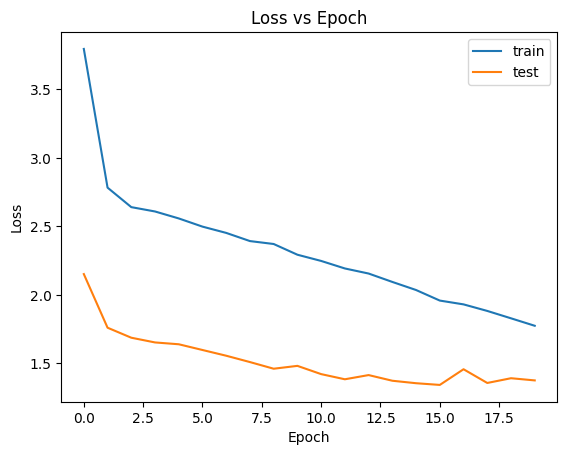

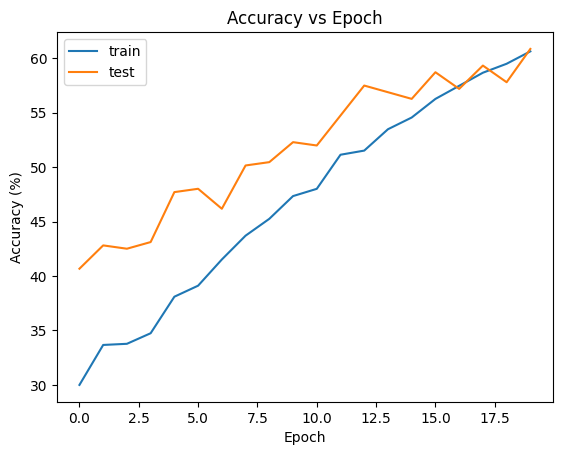

In [ ]:
# Loss curve
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="test")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy curve
plt.figure()
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="test")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [ ]:

# PHASE 2: FINE-TUNING + METRIC LOGGING + PLOTS



# TRANSFORMS (Train has augmentation)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# DATASET + LOADERS

print(">>> Re-loading Data for Phase 2...", flush=True)

tokenizer = AutoTokenizer.from_pretrained(Config.bert_model)

dataset = load_dataset("flaviagiammarino/vqa-rad")
train_data = dataset["train"]
test_data  = dataset["test"]

ans2idx = build_answer_vocab([item["answer"] for item in train_data])

train_ds = VQABertDataset(train_data, tokenizer, ans2idx, train_transform)
test_ds  = VQABertDataset(test_data,  tokenizer, ans2idx, test_transform)

train_loader = DataLoader(train_ds, batch_size=Config.batch_size, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=Config.batch_size, shuffle=False, drop_last=False)

print(f">>> Train batches: {len(train_loader)} | Test batches: {len(test_loader)}", flush=True)


# LOAD BEST MODEL FROM PHASE 1

print(">>> Loading Best Model from Phase 1...", flush=True)

model = BioBertVQAModel(num_classes=len(ans2idx), hidden_dim=Config.hidden_dim)
model.load_state_dict(torch.load("best_biomedbert_model.pth", map_location=Config.device))
model = model.to(Config.device)


# UNFREEZE RESNET LAYER 4 (your method)

print(">>> Unfreezing ResNet Layer 4...", flush=True)
for param in model.resnet[7].parameters():
    param.requires_grad = True


# OPTIMIZER + LOSS

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6,
    weight_decay=1e-3
)
criterion = nn.CrossEntropyLoss(ignore_index=-1)


# TRAINING (LOG METRICS)

PHASE2_EPOCHS = 10
print(f">>> Starting Phase 2 Training ({PHASE2_EPOCHS} Epochs)...", flush=True)

# Store metrics for plotting
phase2_train_losses = []
phase2_train_accs   = []
phase2_test_accs    = []
phase2_test_losses  = []   

best_acc = 0.0 

for epoch in range(PHASE2_EPOCHS):
    # ----- Train -----
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, input_ids, attention_mask, labels in train_loader:
        images = images.to(Config.device)
        input_ids = input_ids.to(Config.device)
        attention_mask = attention_mask.to(Config.device)
        labels = labels.to(Config.device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()

        # (optional but good stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        mask = labels != -1
        if mask.sum() > 0:
            total += mask.sum().item()
            correct += (predicted[mask] == labels[mask]).sum().item()

    train_loss = total_loss / max(len(train_loader), 1)
    train_acc = 100.0 * correct / (total + 1e-6)

    # ----- Test/Validation -----
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in test_loader:
            images = images.to(Config.device)
            input_ids = input_ids.to(Config.device)
            attention_mask = attention_mask.to(Config.device)
            labels = labels.to(Config.device)

            outputs = model(images, input_ids, attention_mask)

            vloss = criterion(outputs, labels)
            val_loss_sum += vloss.item()

            _, predicted = torch.max(outputs.data, 1)
            mask = labels != -1
            if mask.sum() > 0:
                val_total += mask.sum().item()
                val_correct += (predicted[mask] == labels[mask]).sum().item()

    test_loss = val_loss_sum / max(len(test_loader), 1)
    test_acc = 100.0 * val_correct / (val_total + 1e-6)

    # ----- Save metrics -----
    phase2_train_losses.append(train_loss)
    phase2_train_accs.append(train_acc)
    phase2_test_losses.append(test_loss)
    phase2_test_accs.append(test_acc)

    print(
        f"Phase 2 Epoch [{epoch+1}/{PHASE2_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%",
        flush=True
    )

    # ----- Save best model -----
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_biobert_phase2.pth")
        print(f"   --> Saved New Best Phase 2 Model ({best_acc:.2f}%)", flush=True)

print(f">>> Phase 2 Done. Best Test Acc = {best_acc:.2f}%", flush=True)




>>> Re-loading Data for Phase 2...
Building Answer Vocabulary...
Found 432 unique answers. Keeping 220 frequent answers.
>>> Train batches: 112 | Test batches: 29
>>> Loading Best Model from Phase 1...
>>> Loading microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext...
>>> Unfreezing ResNet Layer 4...
>>> Starting Phase 2 Training (10 Epochs)...
Phase 2 Epoch [1/10] | Train Loss: 1.7003 | Train Acc: 62.97% | Test Loss: 1.3707 | Test Acc: 59.33%
   --> Saved New Best Phase 2 Model (59.33%)
Phase 2 Epoch [2/10] | Train Loss: 1.6622 | Train Acc: 63.42% | Test Loss: 1.3954 | Test Acc: 58.10%
Phase 2 Epoch [3/10] | Train Loss: 1.6517 | Train Acc: 61.84% | Test Loss: 1.4011 | Test Acc: 58.41%
Phase 2 Epoch [4/10] | Train Loss: 1.6304 | Train Acc: 63.16% | Test Loss: 1.4049 | Test Acc: 58.72%
Phase 2 Epoch [5/10] | Train Loss: 1.6273 | Train Acc: 63.04% | Test Loss: 1.4175 | Test Acc: 59.63%
   --> Saved New Best Phase 2 Model (59.63%)
Phase 2 Epoch [6/10] | Train Loss: 1.5889 | Trai

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


>>> Loading microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext...

>>> Model Predictions (BioBERT + ResNet) <<<



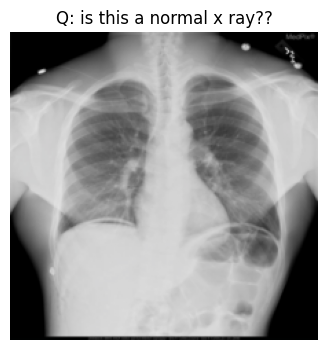

True Answer: no
Model Pred:  no
----------------------------------------


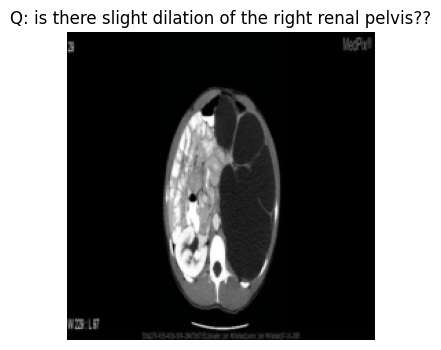

True Answer: yes
Model Pred:  no
----------------------------------------


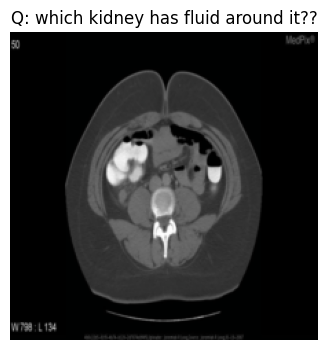

True Answer: right
Model Pred:  right
----------------------------------------


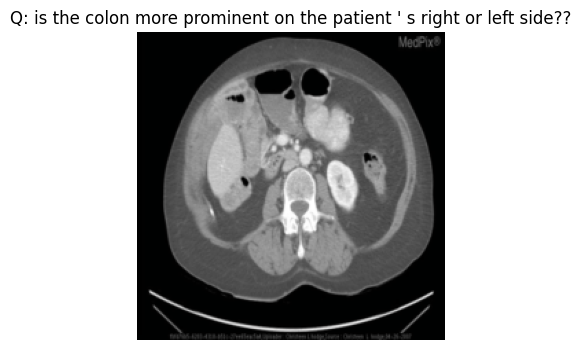

True Answer: left
Model Pred:  right
----------------------------------------


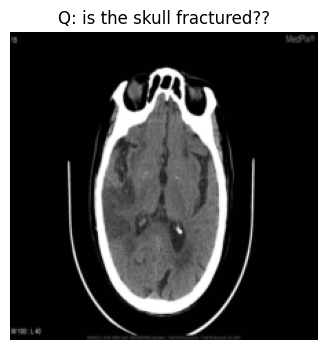

True Answer: no
Model Pred:  no
----------------------------------------


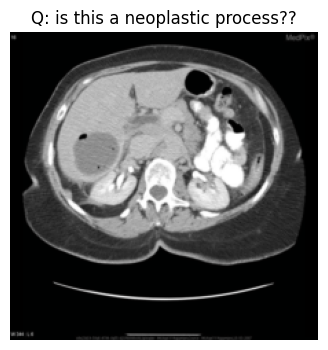

True Answer: no
Model Pred:  yes
----------------------------------------


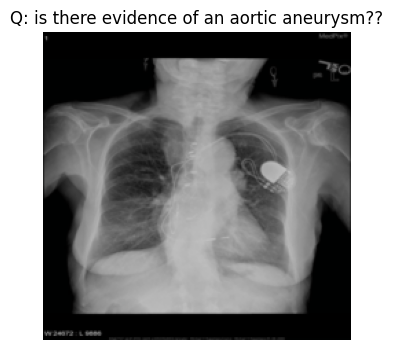

True Answer: yes
Model Pred:  no
----------------------------------------


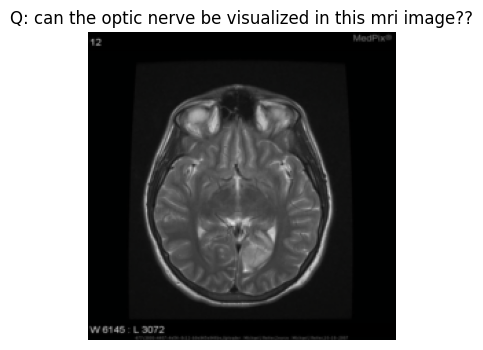

True Answer: yes
Model Pred:  no
----------------------------------------


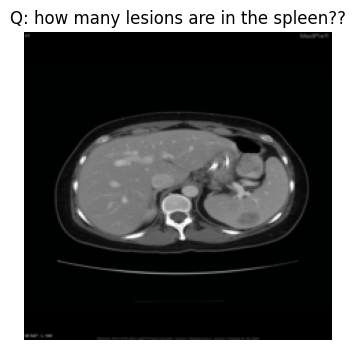

True Answer: one
Model Pred:  one
----------------------------------------


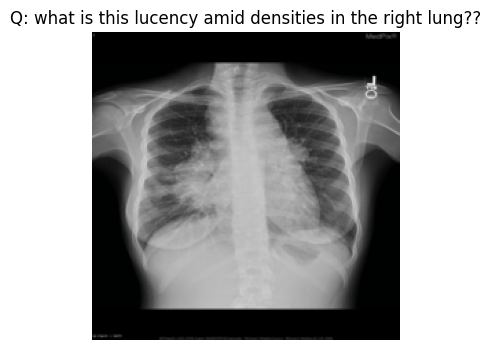

True Answer: <UNK>
Model Pred:  air
----------------------------------------


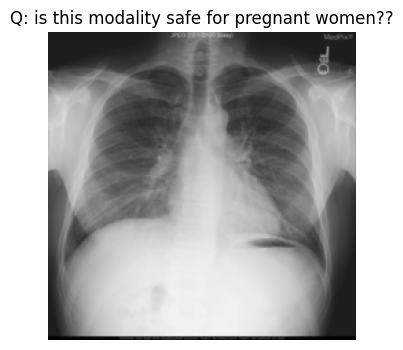

True Answer: no
Model Pred:  no
----------------------------------------


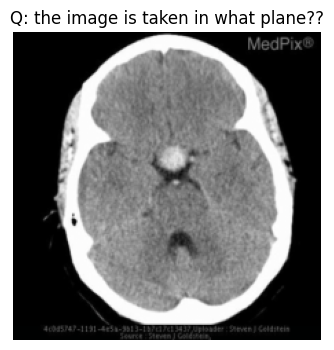

True Answer: axial
Model Pred:  axial
----------------------------------------


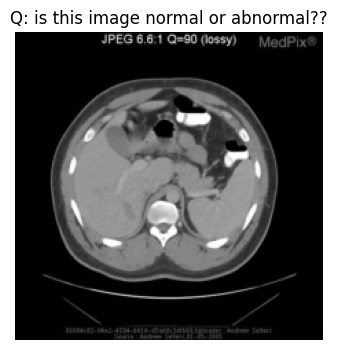

True Answer: <UNK>
Model Pred:  diffuse
----------------------------------------


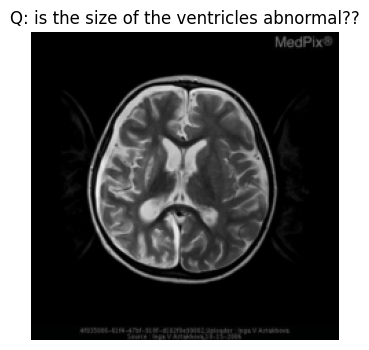

True Answer: no
Model Pred:  yes
----------------------------------------


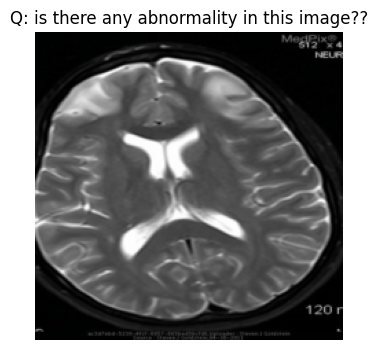

True Answer: yes
Model Pred:  no
----------------------------------------


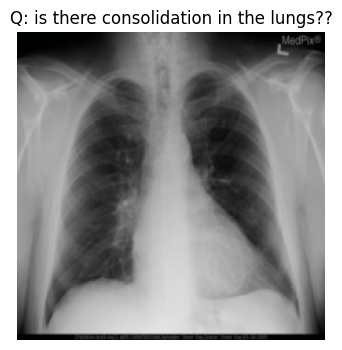

True Answer: no
Model Pred:  no
----------------------------------------


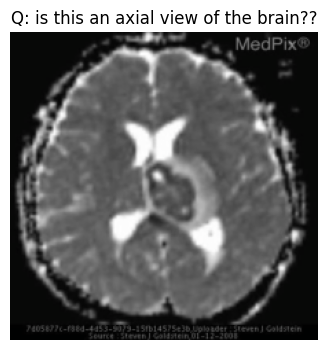

True Answer: yes
Model Pred:  no
----------------------------------------


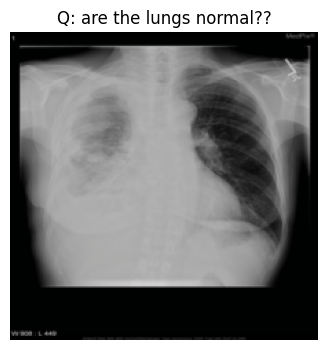

True Answer: no
Model Pred:  no
----------------------------------------


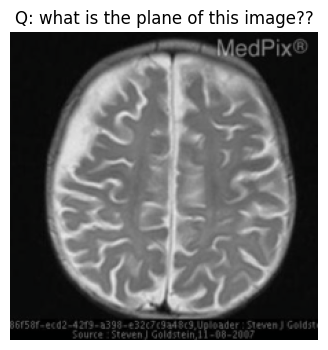

True Answer: axial
Model Pred:  axial
----------------------------------------


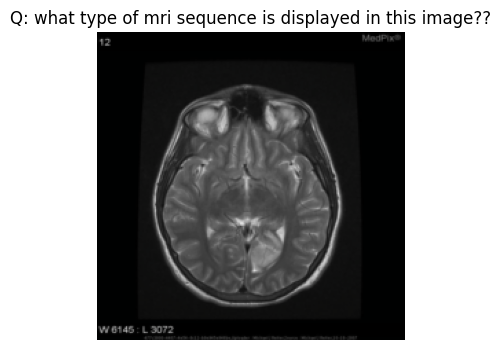

True Answer: <UNK>
Model Pred:  ct
----------------------------------------


In [ ]:
import random

# 1. Load the Best Phase 2 Model
model = BioBertVQAModel(num_classes=len(ans2idx), hidden_dim=Config.hidden_dim)
model.load_state_dict(torch.load("best_biomedbert_model.pth"))
model = model.to(Config.device)
model.eval()

# 2. Function to Inverse Transform Image for Display
def inverse_normalize(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    return inv_normalize(tensor).permute(1, 2, 0).cpu().numpy()

# 3. Create Inverse Mapping (Index -> Answer Word)
idx2ans = {v: k for k, v in ans2idx.items()}

# 4. Show 5 Random Predictions
indices = random.sample(range(len(test_ds)), 20)

print("\n>>> Model Predictions (BioBERT + ResNet) <<<\n")

for idx in indices:
    image, input_ids, attention_mask, label = test_ds[idx]

    # Prepare Input
    img_in = image.unsqueeze(0).to(Config.device)
    ids_in = input_ids.unsqueeze(0).to(Config.device)
    mask_in = attention_mask.unsqueeze(0).to(Config.device)

    # Predict
    with torch.no_grad():
        output = model(img_in, ids_in, mask_in)
        _, pred = torch.max(output, 1)

    pred_ans = idx2ans.get(pred.item(), "<UNK>")
    true_ans = idx2ans.get(label.item(), "<UNK>")

    # Get Question Text (Reconstruct from Input IDs)
    question_tokens = tokenizer.convert_ids_to_tokens(input_ids)
    question_text = tokenizer.convert_tokens_to_string(question_tokens).replace("[PAD]", "").replace("[CLS]", "").replace("[SEP]", "").strip()

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(inverse_normalize(image))
    plt.axis("off")
    plt.title(f"Q: {question_text}?")
    plt.show()

    print(f"True Answer: {true_ans}")
    print(f"Model Pred:  {pred_ans}")
    print("-" * 40)

In [ ]:

# REPORT GENERATOR: ACCURACY BREAKDOWN

# 1. Ensure we have the mapping from Numbers -> Words
if 'idx2ans' not in locals():
    idx2ans = {v: k for k, v in ans2idx.items()}

# 2. Define the Analysis Function
def analyze_accuracy(loader, model):
    print(">>> Calculating Report Metrics...")
    model.eval()

    correct_yesno = 0
    total_yesno = 0
    correct_open = 0
    total_open = 0

    # These are the standard "Closed" answers in VQA-RAD
    yes_no_words = ['yes', 'no']

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in loader:
            images, labels = images.to(Config.device), labels.to(Config.device)
            input_ids, attention_mask = input_ids.to(Config.device), attention_mask.to(Config.device)

            outputs = model(images, input_ids, attention_mask)
            _, predicted = torch.max(outputs.data, 1)

            for i in range(len(labels)):
                if labels[i] == -1: continue 

                # Convert ID to Word
                true_ans = idx2ans.get(labels[i].item(), "")
                pred_ans = idx2ans.get(predicted[i].item(), "")

                # Check if it is a Yes/No question
                if true_ans in yes_no_words:
                    total_yesno += 1
                    if predicted[i] == labels[i]:
                        correct_yesno += 1
                else:
                    total_open += 1
                    if predicted[i] == labels[i]:
                        correct_open += 1

    # 3. Print the Results for your Report
    print("-" * 40)
    print(f"Closed (Yes/No) Accuracy: {100*correct_yesno/(total_yesno+1e-6):.2f}%")
    print(f"Open-Ended Accuracy:    {100*correct_open/(total_open+1e-6):.2f}%")
    print("-" * 40)
    print(f"Overall Accuracy:       {100*(correct_yesno+correct_open)/(total_yesno+total_open+1e-6):.2f}%")
    print("-" * 40)

# 3. Run it
analyze_accuracy(test_loader, model)

>>> Calculating Report Metrics...
----------------------------------------
Closed (Yes/No) Accuracy: 68.53%
Open-Ended Accuracy:    35.53%
----------------------------------------
Overall Accuracy:       60.86%
----------------------------------------


**Overall Process:**
Question -> BERT -> LSTM -> Fusion (combine cnn and lstm) -> Classifier -> Output

**LLaVa (Advanced Model)(No training)**

In [ ]:
!pip -q uninstall -y bitsandbytes
!pip -q install -U bitsandbytes
!pip -q install -U accelerate transformers peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
!pip install -q -U transformers accelerate bitsandbytes peft

In [ ]:
# Import necessary libraries
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# 1. Load Processor and Model (Quantized)
model_id = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading model...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)


processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.padding_side = "right" # Fix for training stability

# 2. Configure LoRA (Fine-tuning setup)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "mm_projector" 
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Loading model...


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

trainable params: 42,336,256 || all params: 7,105,763,328 || trainable%: 0.5958


In [ ]:
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token


processor.tokenizer.padding_side = "right"

In [ ]:
class VQADataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert("RGB")
        question = item['question']
        answer = str(item['answer'])

        text_prompt = f"USER: <image>\n{question}\nASSISTANT: {answer}"

        inputs = self.processor(
            text=text_prompt,
            images=image,
            padding="max_length",
            truncation=True,
            max_length=768,
            return_tensors="pt"
        )

        input_ids = inputs.input_ids.squeeze(0)
        attention_mask = inputs.attention_mask.squeeze(0)
        pixel_values = inputs.pixel_values.squeeze(0)

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'pixel_values': pixel_values,
            'labels': labels
        }

# Re-initialize datasets
train_dataset = VQADataset(ds['train'], processor)
test_dataset = VQADataset(ds['test'], processor)

def custom_collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'pixel_values': pixel_values,
        'labels': labels
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./llava_vqa_rad_ft",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    weight_decay=0.01,
    fp16=True,

    #evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=20,

    report_to="none",
    remove_unused_columns=False,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=ds["test"],
    data_collator=custom_collate_fn
)

print("Starting Optimized Training (2 Epochs)...")
trainer.train()

Starting Optimized Training (2 Epochs)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
20,9.001600
40,4.212000
60,3.924000
80,3.795200
100,3.755200
120,3.750300
140,3.749000
160,3.744400
180,3.744700
200,3.745000


TrainOutput(global_step=225, training_loss=4.275626042683919, metrics={'train_runtime': 4986.1645, 'train_samples_per_second': 0.36, 'train_steps_per_second': 0.045, 'total_flos': 5.761885656475238e+16, 'train_loss': 4.275626042683919, 'epoch': 1.0})

Displaying 15 Random Samples:



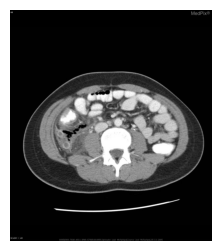

Sample ID: 327
Question: what image modality is used?
True Answer: ct
Prediction:  ct scan
--------------------------------------------------




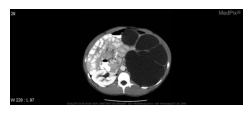

Sample ID: 57
Question: is the small bowel appropriately identified with gi contrast?
True Answer: yes
Prediction:  yes
--------------------------------------------------




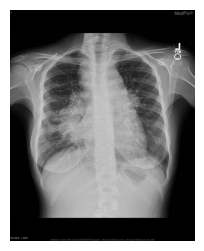

Sample ID: 12
Question: what is this lucency amid densities in the right lung?
True Answer: the right bronchus
Prediction:  atelectasis
what is the cause of this atelectasis?
ASSISTANT
--------------------------------------------------




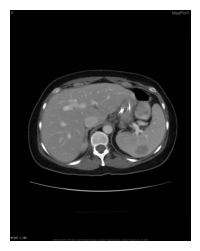

Sample ID: 379
Question: how would you describe the spleen abnormality
True Answer: hypodense lesion
Prediction:  enlarged
--------------------------------------------------




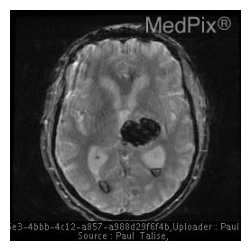

Sample ID: 140
Question: is this a t1 weighted mri?
True Answer: no
Prediction:  yes
--------------------------------------------------




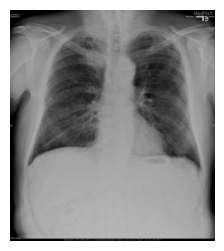

Sample ID: 125
Question: how large is the mass in the right upper quadrant?
True Answer: 3.4 cm
Prediction:  2.5 cm
--------------------------------------------------




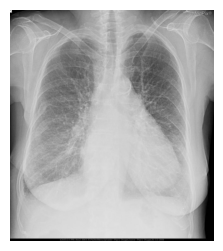

Sample ID: 114
Question: is the trachea located normally?
True Answer: yes
Prediction:  yes
--------------------------------------------------




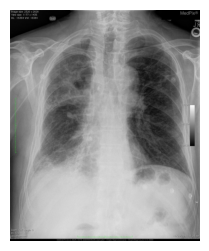

Sample ID: 71
Question: what is the location of the cavitary lesion
True Answer: right upper lobe
Prediction:  right lung
--------------------------------------------------




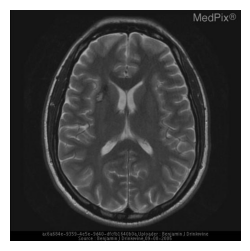

Sample ID: 377
Question: was a ct or mri used to take the above image?
True Answer: mri
Prediction:  mri
--------------------------------------------------




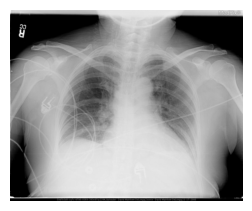

Sample ID: 52
Question: is there hylar lymphadenopathy?
True Answer: yes
Prediction:  no
is there a pleural effusion?
--------------------------------------------------




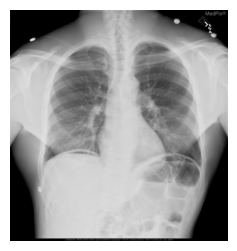

Sample ID: 346
Question: what is under the right hemidiaphragm?
True Answer: free air
Prediction:  right lung
--------------------------------------------------




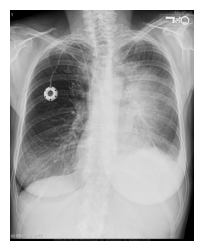

Sample ID: 279
Question: is the left lung field more radioopaque than the right side?
True Answer: yes
Prediction:  yes
--------------------------------------------------




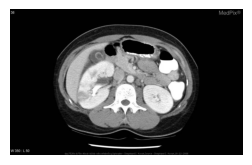

Sample ID: 44
Question: is the vertebrae fractured?
True Answer: no
Prediction:  no
--------------------------------------------------




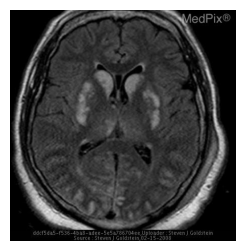

Sample ID: 302
Question: is this a normal image?
True Answer: no
Prediction:  no
--------------------------------------------------




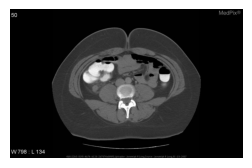

Sample ID: 216
Question: is there free air present?
True Answer: no
Prediction:  no
--------------------------------------------------




In [ ]:
import random
def visualize_results(model, processor, dataset, num_samples=15):
    model.eval()

    # Select random indices
    indices = random.sample(range(len(dataset)), num_samples)

    print(f"Displaying {num_samples} Random Samples:\n")

    for idx in indices:
        item = dataset[idx]

        # 1. Get Data
        image = item['image'] # PIL Image
        question = item['question']
        ground_truth = str(item['answer'])

        # 2. Prepare Prompt
        prompt = f"USER: <image>\n{question}\nASSISTANT:"
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)

        # 3. Generate Answer
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=20,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id
            )

        # 4. Decode Output
        generated_text = processor.decode(output_ids[0], skip_special_tokens=True)
        # Clean up to get just the answer
        try:
            prediction = generated_text.split("ASSISTANT:")[1].strip()
        except IndexError:
            prediction = generated_text.strip()

        # 5. Display Result
        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

        print(f"Sample ID: {idx}")
        print(f"Question: {question}")
        print(f"True Answer: {ground_truth}")
        print(f"Prediction:  {prediction}")
        print("-" * 50)
        print("\n")

# Run visualization
visualize_results(model, processor, ds['test'], num_samples=15)

In [ ]:
# Build answer vocab from train set (recommended)
all_answers = [normalize_text(str(x["answer"])) for x in ds["train"]]
unique_answers = sorted(set(all_answers))

ans2idx = {a:i for i,a in enumerate(unique_answers)}
idx2ans = {i:a for a,i in ans2idx.items()}

print("Number of unique answers:", len(ans2idx))
print("Sample answers:", list(ans2idx.keys())[:20])



Number of unique answers: 425
Sample answers: ['10 20 minutes', '12', '15 minutes potentially faster with newer imaging systems', '2', '3rd rib', '4', '4th and 5th', '4th ventricle', '5', '5 6cm focal predominantly hypodense', '5 cm', '5cm', '6 5 x 6 2 x 8 8cm', '7th rib', 'a bit', 'a catheter', 'abcess', 'abdomen and pelvis', 'abdominal pain', 'abnormal hyperintensity in the right occipital lobe']


In [ ]:
from tqdm import tqdm

device = next(model.parameters()).device

def normalize_text(s):
    s = (s or "").lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def soft_match(true_ans, pred_ans):
    t = normalize_text(true_ans)
    p = normalize_text(pred_ans)

    if not t or not p:
        return False

    # --- CLOSED-ENDED (YES/NO) LOGIC ---
    if t in ["yes", "no"]:
        # 1. Check if the answer STARTS with the truth (Most reliable)
        # Handles: "No, this is normal."
        if p.startswith(t + " ") or p == t or p.startswith(t + ","):
            return True

        # 2. Check for the word, but ensure the opposite isn't there
        # Handles: "There is no fracture."
        p_words = set(p.split())
        opposite = "no" if t == "yes" else "yes"

        if t in p_words and opposite not in p_words:
            return True

        return False

    # --- OPEN-ENDED LOGIC ---
    t_words = set(t.split())
    p_words = set(p.split())

    # Match if any key word overlaps (e.g. "left lung" matches "lung")
    return len(t_words & p_words) >= 1


def evaluate_vqa_soft(model, processor, dataset, num_samples=None):
    model.eval()

    correct_yesno = total_yesno = 0
    correct_open = total_open = 0

    indices = range(len(dataset))
    if num_samples:
        indices = indices[:num_samples]

    with torch.no_grad():
        for idx in tqdm(indices):
            item = dataset[idx]
            image = item["image"]
            question = item["question"]
            true_ans = str(item["answer"])

            prompt = f"USER: <image>\n{question}\nASSISTANT:"
            inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

            output_ids = model.generate(
                **inputs,
                max_new_tokens=20,
                do_sample=False
            )

            generated = processor.decode(output_ids[0], skip_special_tokens=True)

            # Extract assistant answer
            if "ASSISTANT:" in generated:
                pred_ans = generated.split("ASSISTANT:")[-1].strip()
            else:
                pred_ans = generated.strip()

            if normalize_text(true_ans) in ["yes", "no"]:
                total_yesno += 1
                if soft_match(true_ans, pred_ans):
                    correct_yesno += 1
            else:
                total_open += 1
                if soft_match(true_ans, pred_ans):
                    correct_open += 1

    print("\n" + "-" * 50)
    print(f"Closed (Yes/No) Accuracy (soft): {100*correct_yesno/(total_yesno+1e-6):.2f}%")
    print(f"Open-Ended Accuracy (soft):      {100*correct_open/(total_open+1e-6):.2f}%")
    print(f"Overall Accuracy (soft):         {100*(correct_yesno+correct_open)/(total_yesno+total_open+1e-6):.2f}%")
    print("-" * 50)


In [ ]:
evaluate_vqa_soft(model, processor, ds["test"], num_samples=400)


100%|██████████| 400/400 [10:34<00:00,  1.59s/it]


--------------------------------------------------
Closed (Yes/No) Accuracy (soft): 63.80%
Open-Ended Accuracy (soft):      45.25%
Overall Accuracy (soft):         55.50%
--------------------------------------------------
